# Lecture : Graph Convolutional Networks

## Lab 02 : GCNs -- Solution -- PyTorch Geometric version

### Xavier Bresson, Nian Liu, Ryoji Kubo

Kipf, Welling, Semi-supervised classification with graph convolutional networks, 2016   
https://arxiv.org/pdf/1609.02907.pdf

This notebook is the [PyTorch Geometric (PyG)](https://pytorch-geometric.readthedocs.io) counterpart of `code02_solution.ipynb`.
The artificial graph dataset is still generated with DGL (`MiniGCDataset`), but **every graph is converted into a
PyG `Data` object** and the GCN is implemented **from scratch** with PyG's `MessagePassing` class (we do *not* call
the ready-made `torch_geometric.nn.GCNConv`).

In [1]:
# For Google Colaboratory
import sys, os
if 'google.colab' in sys.modules:
    # mount google drive
    from google.colab import drive
    drive.mount('/content/gdrive')
    path_to_file = '/content/gdrive/My Drive/CS5284_2026_codes/06_Graph_Convnets'
    print(path_to_file)
    # change current path to the folder containing "path_to_file"
    os.chdir(path_to_file)
    !pwd
    !pip -q install torch_geometric                                            # Install PyG
    !pip -q install -f https://data.dgl.ai/wheels/torch-2.6/repo.html dgl==2.5.0 # Install DGL (dataset only)


In [2]:
# Libraries
import dgl                                  # only used to generate the artificial dataset
from dgl.data import MiniGCDataset
import matplotlib.pyplot as plt
import networkx as nx
import torch
from torch import Tensor
from torch.utils.data import DataLoader
import torch.nn as nn
import time

# PyTorch Geometric
import torch_geometric
from torch_geometric.data import Data, Batch
from torch_geometric.nn import MessagePassing, global_mean_pool
from torch_geometric.utils import degree, to_networkx

print('torch:', torch.__version__)
print('torch_geometric:', torch_geometric.__version__)
print('dgl:', dgl.__version__)

torch: 2.1.2
torch_geometric: 2.5.1
dgl: 1.0.2


# Visualize the artifical graph dataset used in this notebook

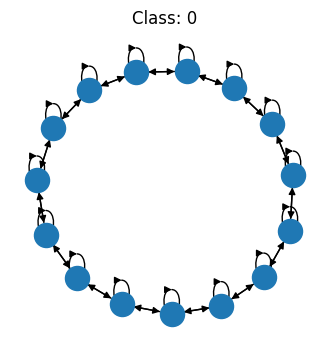

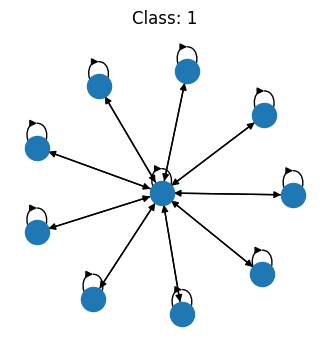

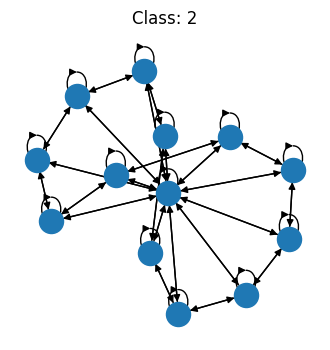

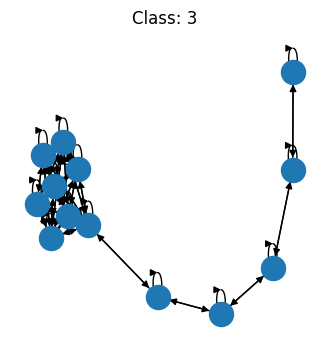

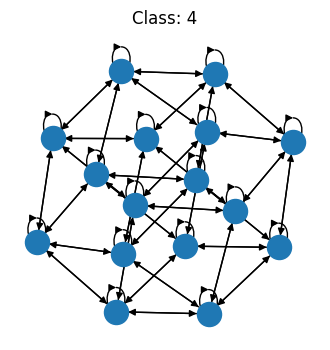

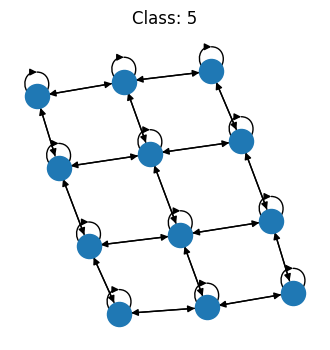

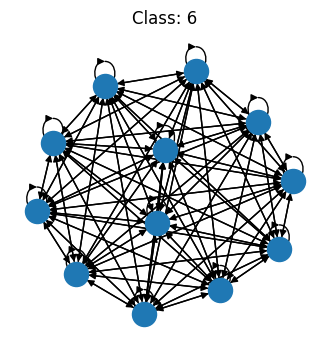

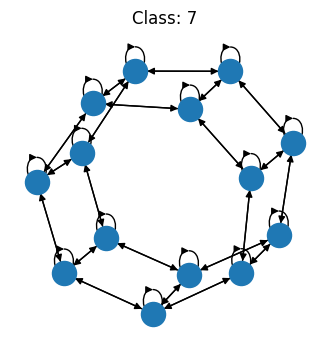

In [3]:
dataset = MiniGCDataset(8, 10, 20) # DGL artificial dataset

# visualise the 8 classes of graphs
for c in range(8):
    graph, label = dataset[c]
    fig, ax = plt.subplots(figsize=(4,4))
    nx.draw(graph.to_networkx(), ax=ax)
    ax.set_title('Class: {:d}'.format(label))
    plt.show()

# Generate train, val and test datasets 

## Question 1: Convert the DGL graphs into PyG `Data` objects and add a node feature with the in-degree

A PyG graph is a `Data` object holding plain tensors:
  - `data.edge_index` of size `(2, num_edges)`: `edge_index[0]` = source nodes $j$, `edge_index[1]` = destination nodes $i$
    (PyG's default message flow is `source_to_target`, i.e. $j \rightarrow i$),
  - `data.x` of size `(num_nodes, num_node_features)`: the node features,
  - `data.y`: the graph label (one value per graph for graph classification).

Contrary to DGL, PyG has no `in_degrees()` method attached to the graph: the degrees are computed from `edge_index`
with the helper [`torch_geometric.utils.degree()`](https://pytorch-geometric.readthedocs.io/en/latest/modules/utils.html#torch_geometric.utils.degree).
Counting how many times a node appears as a **destination** in `edge_index[1]` gives the in-degree.

Hints: You may use `graph.edges()` (DGL), `torch.stack()`, `degree()`, `.view()`, `.float()`

In [4]:
# Convert a DGL graph into a PyG Data object, with node feature = node in-degree
def dgl_to_pyg(dgl_graph, label):

    # DGL edge list : src = j (source), dst = i (destination)
    src, dst = dgl_graph.edges()
    num_nodes = dgl_graph.num_nodes()

    ########################################
    # YOUR CODE STARTS
    # edge_index.size()=(2,num_edges) with edge_index[0]=src/j and edge_index[1]=dst/i
    # x.size()=(num_nodes,1) and x.type()=torch.FloatTensor, with x = node in-degree
    ########################################
    edge_index = torch.stack([src.long(), dst.long()], dim=0)                 # (2,num_edges)
    x = degree(edge_index[1], num_nodes=num_nodes).view(-1, 1).float()        # node feat is in-degree
    ########################################
    # YOUR CODE ENDS
    ########################################

    y = torch.tensor([label], dtype=torch.long)                               # graph label, size (1,)
    return Data(x=x, edge_index=edge_index, y=y, num_nodes=num_nodes)


# Convert a whole DGL dataset into a list of PyG Data objects
def convert_dataset(dgl_dataset):
    return [ dgl_to_pyg(graph, int(label)) for (graph, label) in dgl_dataset ]


# Generate graph datasets
trainset = convert_dataset(MiniGCDataset(350, 10, 20))
testset  = convert_dataset(MiniGCDataset(100, 10, 20))
valset   = convert_dataset(MiniGCDataset(100, 10, 20))

print(trainset[0])
print('x:', trainset[0].x.size(), trainset[0].x.dtype)
print('edge_index:', trainset[0].edge_index.size(), trainset[0].edge_index.dtype)
print('y:', trainset[0].y)
print('in-degree of the 5 first nodes:', trainset[0].x[:5].view(-1))

Data(x=[15, 1], edge_index=[2, 45], y=[1], num_nodes=15)
x: torch.Size([15, 1]) torch.float32
edge_index: torch.Size([2, 45]) torch.int64
y: tensor([0])
in-degree of the 5 first nodes: tensor([3., 3., 3., 3., 3.])


## Question 2: Define the collate function to generate a batch of PyG graphs and test it

Batch a collection of PyG graphs into one large graph for more efficient computation.

As in DGL, batching builds a **block-diagonal** adjacency matrix: the node features are concatenated along the
node dimension and the node indices stored in `edge_index` are shifted by the cumulated number of nodes of the
previous graphs. The batched graph additionally carries a vector `batch` of size `(num_nodes_of_the_batch,)` that
maps every node to the index of the graph it belongs to -- this is what allows the graph-level readout later on.

Hints: You may use the PyG module [Batch.from_data_list()](https://pytorch-geometric.readthedocs.io/en/latest/modules/data.html#torch_geometric.data.Batch).

In [5]:
# collate function prepares a batch of graphs and labels
def collate(samples):
    # Input sample is a list of "batch_size" PyG Data objects (each one carries its own label in .y)
    ########################################
    # YOUR CODE STARTS
    # Create the PyG batch of graphs, which is equivalent to build a block diagonal matrix with all graphs in the batch
    ########################################
    batch_graphs = Batch.from_data_list(samples) # batch of graphs
    ########################################
    # YOUR CODE ENDS
    ########################################
    batch_labels = batch_graphs.y                # batch of labels
    return batch_graphs, batch_labels

# Generate a batch of graphs
batch_size = 10
train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True, collate_fn=collate)
batch_graphs, batch_labels = list(train_loader)[0]
print(batch_graphs)
print(batch_labels)
batch_x = batch_graphs.x
print('batch_x:', batch_x.size())
print('batch vector (node => graph index):', batch_graphs.batch.size(), batch_graphs.batch[:20])
print('nb of graphs in the batch:', batch_graphs.num_graphs)

DataBatch(x=[144, 1], edge_index=[2, 706], y=[10], num_nodes=144, batch=[144], ptr=[11])
tensor([4, 5, 1, 5, 1, 4, 1, 6, 0, 4])
batch_x: torch.Size([144, 1])
batch vector (node => graph index): torch.Size([144]) tensor([0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])
nb of graphs in the batch: 10


Let us check that the batched `edge_index` is indeed the block-diagonal version of the individual `edge_index`:
the edges of the $k$-th graph are the original ones shifted by the number of nodes of the graphs $0,\dots,k-1$.

In [6]:
# Sanity check of the block-diagonal batching
two_graphs = [trainset[0], trainset[1]]
b = Batch.from_data_list(two_graphs)
n0 = two_graphs[0].num_nodes
print('graph 0: num_nodes={}, edge_index max index={}'.format(n0, int(two_graphs[0].edge_index.max())))
print('graph 1: num_nodes={}, edge_index max index={}'.format(two_graphs[1].num_nodes, int(two_graphs[1].edge_index.max())))
print('batch  : num_nodes={}, edge_index max index={}'.format(b.num_nodes, int(b.edge_index.max())))
num_edges_0 = two_graphs[0].edge_index.size(1)
shifted = b.edge_index[:, num_edges_0:] - n0            # edges of graph 1 in the batch, shifted back
print('edges of graph 1 recovered from the batch:', torch.equal(shifted, two_graphs[1].edge_index))

# Note: PyG also provides its own loader, torch_geometric.loader.DataLoader, which calls Batch.from_data_list()
# internally, i.e. it is exactly the collate function written above. We keep the explicit version for clarity.

graph 0: num_nodes=15, edge_index max index=14
graph 1: num_nodes=10, edge_index max index=9
batch  : num_nodes=25, edge_index max index=24
edges of graph 1 recovered from the batch: True


## Question 3: Design the class of GCN networks with PyG

Node update equation:  
\begin{align}
h_i^{\ell+1} &=& h_i^{\ell} + \text{ReLU} \left( \frac{1}{\sqrt{d_i}} \sum_{j\sim i} \frac{1}{\sqrt{d_j}} W^\ell h_j^{\ell} \right)
\end{align}

PyG implements message-passing with the class
[`MessagePassing`](https://pytorch-geometric.readthedocs.io/en/latest/modules/nn.html#torch_geometric.nn.MessagePassing).
Calling `self.propagate(edge_index, **kwargs)` runs the three standard steps

$$ \texttt{message()} \;\longrightarrow\; \texttt{aggregate()} \;\longrightarrow\; \texttt{update()} $$

which are the exact counterparts of DGL's `message_func()` / `reduce_func()`.

Instructions:

Step 1: Pass node features along edges (src/j => dst/i) in `message()`.
  - Any tensor `xx` given to `propagate()` can be read inside `message()` as `xx_j` (feature of the **source** node $j$
    of each edge, i.e. DGL's `edges.src['xx']`) or as `xx_i` (feature of the **destination** node $i$, i.e. `edges.dst['xx']`).
  - PyG performs the lifting automatically: `xx_j` is nothing but `xx[edge_index[0]]`, of size `(num_edges, dim)`.
  
Step 2: The messages are collected on the destination node $i$ by `aggregate()`.
  - This is selected with the constructor argument `aggr='add'`, which sums all the messages arriving at node $i$
    -- the counterpart of DGL's `torch.sum(..., dim=1)` over `nodes.mailbox`.
  - Contrary to DGL, no explicit mailbox is materialized: the sum is done with a scatter operation, which is
    memory efficient and supports nodes with different numbers of neighbours.

Note on `propagate_type`: PyG compiles a specialized `propagate()` for every layer class, and it usually infers
the names/types of its arguments by *parsing the source code* of the class. This parsing is unavailable for a class
defined in a notebook cell, so the class attribute `propagate_type = {'Wh': Tensor, 'inv_sqrt_d': Tensor}` declares
them explicitly. Keep it whenever you write a `MessagePassing` layer in a notebook.

In [7]:
# MLP layer for classification
class MLP_layer(nn.Module): 
    
    def __init__(self, input_dim, output_dim, L=2): # L = nb of hidden layers
        super(MLP_layer, self).__init__()
        list_FC_layers = [ nn.Linear( input_dim, input_dim, bias=True ) for l in range(L) ]
        list_FC_layers.append(nn.Linear( input_dim, output_dim , bias=True ))
        self.FC_layers = nn.ModuleList(list_FC_layers)
        self.L = L
        
    def forward(self, x):
        y = x
        for l in range(self.L):
            y = self.FC_layers[l](y)
            y = torch.relu(y)
        y = self.FC_layers[self.L](y)
        return y

        
# class of GCN layer
class GCN_layer(MessagePassing):
    
    # Declare the type of the tensors that will be given to propagate().
    # PyG compiles a specialized propagate() function for each layer class, and it normally reads
    # these types by parsing the source code of the class. Source parsing is not available when a
    # class is defined in a notebook cell, so we declare the types explicitly -- this makes the
    # layer work identically in a script, in Jupyter and in Colab (it is also what TorchScript needs).
    propagate_type = {'Wh': Tensor, 'inv_sqrt_d': Tensor}
    
    def __init__(self, input_dim, output_dim):
        # aggr='add' : the messages arriving at node i are summed  => sum_{j~i}
        # flow='source_to_target' : edge_index[0]=j is the source, edge_index[1]=i is the destination
        super(GCN_layer, self).__init__(aggr='add', flow='source_to_target')
        self.W = nn.Linear(input_dim, output_dim, bias=True)
        
    # Step 1 of message-passing with PyG:
    #   Node features are passed along edges (src/j => dst/i).
    #   The "_j" suffix asks PyG for the value of the tensor at the source node j of each edge,
    #   i.e. Wh_j = Wh[edge_index[0]] and inv_sqrt_d_j = inv_sqrt_d[edge_index[0]].
    #   The returned tensor has size (num_edges, output_dim).
    def message(self, Wh_j, inv_sqrt_d_j):
        ########################################
        # YOUR CODE STARTS
        # Step 1: Pass the message 1/sqrt(d_j) * Wh_j from node j to node i
        ########################################
        msg = inv_sqrt_d_j * Wh_j # 1/sqrt(d_j) * Wh_j
        ########################################
        # YOUR CODE ENDS
        ########################################
        return msg

    # Step 2 of message-passing with PyG:
    #   propagate() calls message(), then aggregates the messages on the destination nodes i with aggr='add',
    #   which computes  h_i = sum_{j~i} 1/sqrt(d_j) * Wh_j.
    #   (the default update() is the identity, so the aggregation result is directly returned)
    def forward(self, h, edge_index):
        h_in = h # residual connection
        Wh = self.W(h) # linear transformation
        d = degree(edge_index[1], num_nodes=h.size(0)).view(-1, 1).float() # in-degree d_i
        inv_sqrt_d = torch.pow(d, -0.5) # 1/sqrt(d_i), also used as 1/sqrt(d_j) inside message()
        ########################################
        # YOUR CODE STARTS
        # Step 2: Update the node features with PyG. The tensors passed to propagate() are the ones
        #         read as Wh_j and inv_sqrt_d_j in message(). The explicit "size" guarantees that the
        #         output has one row per node, even for nodes without incoming edge.
        ########################################
        h = self.propagate(edge_index, Wh=Wh, inv_sqrt_d=inv_sqrt_d, size=(h.size(0), h.size(0)))
        ########################################
        # YOUR CODE ENDS
        ########################################
        h = inv_sqrt_d * h # h_i / sqrt(d_i)
        h = torch.relu(h) # non-linear activation
        h = h_in + h # residual connection
        return h
    
    
class GCN_net(nn.Module):
    
    def __init__(self, net_parameters):
        super(GCN_net, self).__init__()
        input_dim = net_parameters['input_dim']
        hidden_dim = net_parameters['hidden_dim']
        output_dim = net_parameters['output_dim']
        L = net_parameters['L']
        self.embedding_h = nn.Linear(input_dim, hidden_dim)
        self.GCN_layers = nn.ModuleList([ GCN_layer(hidden_dim, hidden_dim) for _ in range(L) ]) 
        self.MLP_layer = MLP_layer(hidden_dim, output_dim)
        
    def forward(self, h, edge_index, batch_vector):
        
        # input embedding
        h = self.embedding_h(h)
        
        # graph convnet layers
        for GCNlayer in self.GCN_layers:
            h = GCNlayer(h, edge_index)
        
        # MLP classifier
        # global_mean_pool() averages the node features of each graph of the batch, using the "batch" vector
        # that maps every node to its graph index. It is the PyG counterpart of dgl.mean_nodes().
        y = global_mean_pool(h, batch_vector) # size (num_graphs, hidden_dim)
        y = self.MLP_layer(y)
        
        return y    
    
    def loss(self, y_scores, y_labels):
        loss = nn.CrossEntropyLoss()(y_scores, y_labels)
        return loss        
        
    def accuracy(self, scores, targets):
        scores = scores.detach().argmax(dim=1)
        acc = (scores==targets).float().sum().item()
        return acc
    
    def update(self, lr):       
        update = torch.optim.Adam( self.parameters(), lr=lr )
        return update


# Instantiate one network (testing)
net_parameters = {}
net_parameters['input_dim'] = 1
net_parameters['hidden_dim'] = 128
net_parameters['output_dim'] = 8 # nb of classes
net_parameters['L'] = 4
net = GCN_net(net_parameters)
print(net)

def display_num_param(net):
    nb_param = 0
    for param in net.parameters():
        nb_param += param.numel()
    print('Number of parameters: {} ({:.2f} million)'.format(nb_param, nb_param/1e6))
    return nb_param/1e6
_ = display_num_param(net)

GCN_net(
  (embedding_h): Linear(in_features=1, out_features=128, bias=True)
  (GCN_layers): ModuleList(
    (0-3): 4 x GCN_layer()
  )
  (MLP_layer): MLP_layer(
    (FC_layers): ModuleList(
      (0-1): 2 x Linear(in_features=128, out_features=128, bias=True)
      (2): Linear(in_features=128, out_features=8, bias=True)
    )
  )
)
Number of parameters: 100360 (0.10 million)


### What does `propagate()` actually do?

`propagate()` is *not* a black box: it lifts the node tensors to the edges, calls `message()`, and scatters the
result back to the destination nodes. The cell below re-implements one GCN layer with plain PyTorch indexing
(`Wh[src]` for the lifting, `index_add_` for the sum over the neighbours) and checks that it returns exactly the
same output. The same cell also re-implements the graph readout `global_mean_pool()`.

In [8]:
# One GCN layer written without MessagePassing, to show what propagate() computes
def gcn_layer_from_scratch(layer, h, edge_index):
    src, dst = edge_index[0], edge_index[1]                     # src = j, dst = i
    h_in = h
    Wh = layer.W(h)
    d = degree(dst, num_nodes=h.size(0)).view(-1, 1).float()
    inv_sqrt_d = torch.pow(d, -0.5)
    msg = inv_sqrt_d[src] * Wh[src]                             # message()  : "_j" lifting = indexing with src
    h = torch.zeros(h.size(0), Wh.size(1), dtype=Wh.dtype)
    h = h.index_add_(0, dst, msg)                               # aggregate(aggr='add') : sum over j~i
    h = inv_sqrt_d * h
    h = torch.relu(h)
    h = h_in + h
    return h

# Mean readout written without global_mean_pool()
def mean_pool_from_scratch(h, batch_vector, num_graphs):
    sum_h = torch.zeros(num_graphs, h.size(1), dtype=h.dtype).index_add_(0, batch_vector, h)
    nb_nodes = torch.zeros(num_graphs, 1, dtype=h.dtype).index_add_(0, batch_vector, torch.ones(h.size(0), 1))
    return sum_h / nb_nodes

with torch.no_grad():
    layer = GCN_layer(128, 128)
    h = torch.randn(batch_graphs.num_nodes, 128)
    h_pyg = layer(h, batch_graphs.edge_index)
    h_scratch = gcn_layer_from_scratch(layer, h, batch_graphs.edge_index)
    print('max |propagate - from scratch| =', (h_pyg - h_scratch).abs().max().item())
    y_pyg = global_mean_pool(h_pyg, batch_graphs.batch)
    y_scratch = mean_pool_from_scratch(h_pyg, batch_graphs.batch, batch_graphs.num_graphs)
    print('max |global_mean_pool - from scratch| =', (y_pyg - y_scratch).abs().max().item())

max |propagate - from scratch| = 0.0
max |global_mean_pool - from scratch| = 0.0


# Train the network

In [9]:
def run_one_epoch(net, data_loader, train=True):
    if train:
        net.train()
    else:
        net.eval()
    epoch_loss = 0
    epoch_acc = 0
    nb_data = 0
    gpu_mem = 0
    for iter, (batch_graphs, batch_labels) in enumerate(data_loader):
        batch_x = batch_graphs.x
        batch_edge_index = batch_graphs.edge_index
        batch_vector = batch_graphs.batch
        batch_labels = batch_labels
        batch_scores = net.forward(batch_x, batch_edge_index, batch_vector)
        loss = net.loss(batch_scores, batch_labels)
        if train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        epoch_loss += loss.detach().item()
        epoch_acc += net.accuracy(batch_scores,batch_labels)
        nb_data += batch_labels.size(0)
    epoch_loss /= (iter + 1)
    epoch_acc /= nb_data
    return epoch_loss, epoch_acc 


# dataset loaders
train_loader = DataLoader(trainset, batch_size=50, shuffle=True, collate_fn=collate)
test_loader = DataLoader(testset, batch_size=50, shuffle=False, collate_fn=collate)
val_loader = DataLoader(valset, batch_size=50, shuffle=False, drop_last=False, collate_fn=collate)

# Instantiate one network
net_parameters = {}
net_parameters['input_dim'] = 1
net_parameters['hidden_dim'] = 128
net_parameters['output_dim'] = 8 # nb of classes
net_parameters['L'] = 4
net = GCN_net(net_parameters)
display_num_param(net)

# optimizer
optimizer = torch.optim.Adam(net.parameters(), lr=0.0001)

# training loop
for epoch in range(50):
    start = time.time()
    epoch_train_loss, epoch_train_acc = run_one_epoch(net, train_loader, True)
    with torch.no_grad(): 
        epoch_test_loss, epoch_test_acc = run_one_epoch(net, test_loader, False)
        epoch_val_loss, epoch_val_acc = run_one_epoch(net, val_loader, False)  
    if not epoch%2:
        print('Epoch {}, time {:.4f}, train_loss: {:.4f}, test_loss: {:.4f}, val_loss: {:.4f}'.format(epoch, time.time()-start, epoch_train_loss, epoch_test_loss, epoch_val_loss))
        print('                      train_acc: {:.4f}, test_acc: {:.4f}, val_acc: {:.4f}'.format(epoch_train_acc, epoch_test_acc, epoch_val_acc))

Number of parameters: 100360 (0.10 million)
Epoch 0, time 0.0993, train_loss: 2.3419, test_loss: 2.1261, val_loss: 2.1261
                      train_acc: 0.1400, test_acc: 0.1600, val_acc: 0.1600
Epoch 2, time 0.0715, train_loss: 1.9769, test_loss: 1.9884, val_loss: 1.9884
                      train_acc: 0.1229, test_acc: 0.1200, val_acc: 0.1200
Epoch 4, time 0.0621, train_loss: 1.9440, test_loss: 1.9549, val_loss: 1.9549
                      train_acc: 0.1229, test_acc: 0.1200, val_acc: 0.1200
Epoch 6, time 0.0627, train_loss: 1.9185, test_loss: 1.9364, val_loss: 1.9364
                      train_acc: 0.1229, test_acc: 0.1200, val_acc: 0.1200
Epoch 8, time 0.0667, train_loss: 1.9039, test_loss: 1.9195, val_loss: 1.9195
                      train_acc: 0.1229, test_acc: 0.1200, val_acc: 0.1200
Epoch 10, time 0.0676, train_loss: 1.8826, test_loss: 1.8964, val_loss: 1.8964
                      train_acc: 0.1229, test_acc: 0.1200, val_acc: 0.1200
Epoch 12, time 0.0692, train_loss: 1.